# EDA


Notebook này phân tích nhanh tập huấn luyện cho bài toán sinh lời giải toán tiếng Việt. Mục tiêu là kiểm tra cấu trúc dữ liệu, chất lượng trường tiếng Việt, phân bố loại bài, độ dài văn bản, khả năng trích đáp án số và mức độ trùng lặp.

Phân tích chỉ đọc dữ liệu từ `data/train.json`, không chỉnh sửa dữ liệu gốc.

## Thiết lập môi trường

Cell này khai báo thư viện, đường dẫn và một số hàm hiển thị. Nếu chạy notebook từ thư mục `scripts`, biến `PROJECT_ROOT` sẽ tự trỏ về thư mục gốc của repository.

In [5]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import json
import math
import re

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
TRAIN_PATH = PROJECT_ROOT / ".." / "models" / "datasets" / "train.json"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_PATH:", TRAIN_PATH)
print("File tồn tại:", TRAIN_PATH.exists())
if TRAIN_PATH.exists():
    print("Kích thước file MB:", round(TRAIN_PATH.stat().st_size / 1024 / 1024, 2))

PROJECT_ROOT: d:\.Kỳ II năm Ba\DL\BTL\viet-gpt2-math-word-problems
TRAIN_PATH: d:\.Kỳ II năm Ba\DL\BTL\viet-gpt2-math-word-problems\..\models\datasets\train.json
File tồn tại: True
Kích thước file MB: 203.38


## Đọc dữ liệu

`train.json` trong repository hiện là JSONL: mỗi dòng là một object JSON. Hàm dưới đây vẫn hỗ trợ thêm trường hợp file là JSON array để notebook bền hơn khi cấu trúc file thay đổi.

In [6]:
def iter_records(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {path}")

    with path.open("r", encoding="utf-8-sig") as f:
        first = f.read(1)
        f.seek(0)
        if first == "[":
            for item in json.load(f):
                yield item
        else:
            for line_no, line in enumerate(f, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    yield json.loads(line)
                except json.JSONDecodeError as exc:
                    raise ValueError(f"Lỗi JSON ở dòng {line_no}: {exc}") from exc


def preview_text(text, max_chars=140):
    text = re.sub(r"\s+", " ", str(text or "")).strip()
    return text if len(text) <= max_chars else text[:max_chars] + "..."


def word_count(text):
    return len(re.findall(r"\S+", str(text or "")))


def normalized_hash(text):
    text = re.sub(r"\s+", " ", str(text or "")).strip().lower()
    return hashlib.blake2b(text.encode("utf-8"), digest_size=16).hexdigest()


NUMBER_PATTERN = r"[-+]?\d+(?:[\.,]\d+)?"
ANSWER_PATTERNS = [
    rf"Đáp án là\s*[:：]?\s*({NUMBER_PATTERN})",
    rf"Câu trả lời là\s*[:：]?\s*({NUMBER_PATTERN})",
    rf"####\s*({NUMBER_PATTERN})",
]


def parse_number(value):
    value = str(value).strip().replace(" ", "")
    if "," in value and "." in value:
        if value.rfind(",") > value.rfind("."):
            value = value.replace(".", "").replace(",", ".")
        else:
            value = value.replace(",", "")
    elif "," in value:
        value = value.replace(",", ".")
    try:
        parsed = float(value)
    except ValueError:
        return None
    return parsed if math.isfinite(parsed) else None


def extract_answer(text):
    text = str(text or "")
    for pattern in ANSWER_PATTERNS:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            parsed = parse_number(match.group(1))
            if parsed is not None:
                return parsed
    return None

## Tạo bảng đặc trưng

Cell này duyệt toàn bộ file một lần và tạo bảng đặc trưng gọn. Bảng không giữ toàn bộ lời giải, chỉ giữ đoạn xem trước để giảm bộ nhớ nhưng vẫn đủ cho kiểm tra thủ công.

In [7]:
rows = []
field_counter = Counter()
missing_counter = Counter()
query_hash_counter = Counter()
response_hash_counter = Counter()
pair_hash_counter = Counter()
query_first_preview = {}
response_first_preview = {}

required_fields = ["query_vi", "response_vi", "type"]

for idx, record in enumerate(iter_records(TRAIN_PATH)):
    field_counter.update(record.keys())
    for field in required_fields:
        if not record.get(field):
            missing_counter[field] += 1

    query_vi = record.get("query_vi", "")
    response_vi = record.get("response_vi", "")
    problem_type = record.get("type", "")
    answer = extract_answer(response_vi)

    q_hash = normalized_hash(query_vi)
    r_hash = normalized_hash(response_vi)
    p_hash = normalized_hash(query_vi + "\n" + response_vi)
    query_hash_counter[q_hash] += 1
    response_hash_counter[r_hash] += 1
    pair_hash_counter[p_hash] += 1
    query_first_preview.setdefault(q_hash, preview_text(query_vi))
    response_first_preview.setdefault(r_hash, preview_text(response_vi))

    rows.append({
        "index": idx,
        "type": problem_type,
        "query_chars": len(str(query_vi)),
        "response_chars": len(str(response_vi)),
        "query_words": word_count(query_vi),
        "response_words": word_count(response_vi),
        "has_query_vi": bool(query_vi),
        "has_response_vi": bool(response_vi),
        "answer": answer,
        "has_answer": answer is not None,
        "query_preview": preview_text(query_vi),
        "response_preview": preview_text(response_vi),
    })

df = pd.DataFrame(rows)
print("Số dòng:", len(df))
df.head()

Số dòng: 95400


,index,type,query_chars,response_chars,query_words,response_words,has_query_vi,has_response_vi,answer,has_answer,query_preview,response_preview
0,0,GSM_AnsAug,404,351,91,86,True,True,1200.0,True,Bridgette và Alex sắp kết hôn. Bridgette đang mời 84 khách và Alex đang mời 2/3 số khách đó. Họ thuê một người phục vụ ăn uống để chuẩn bị b...,"Bridgette đang mời 84 khách và Alex đang mời 2/3 số khách đó, tức là 84 * 2/3 = 56 khách. Vậy tổng số khách là 84 + 56 = 140 khách. Người ph..."
1,1,MATH_AnsAug,186,212,44,45,True,True,253.0,True,"23 người tham dự một bữa tiệc. Mỗi người bắt tay tối đa 22 người khác. Số lần bắt tay tối đa có thể là bao nhiêu, giả sử rằng bất kỳ hai ngư...","Để tối đa hóa số lần bắt tay, mỗi người nên bắt tay với mọi người khác. Tuy nhiên, mỗi người chỉ được bắt tay tối đa 22 người khác. Vì vậy, ..."
2,2,GSM_SV,421,853,93,230,True,True,2.0,True,"Bob, Tom, Sally và Jerry ăn tối tại tiệm bánh pizza yêu thích của họ. Họ quyết định chia nhau x pizza. Bob đã tự mình ăn nửa chiếc bánh pizz...","Để giải quyết vấn đề này, chúng ta cần xác định giá trị của x, đại diện cho số lượng pizza mà họ đã chia sẻ. Hãy chia nhỏ thông tin đã cho: ..."
3,3,GSM_AnsAug,335,465,80,119,True,True,52.0,True,"Hans đã đặt bàn tại một nhà hàng sang trọng cho 12 người. Anh ta phải đặt cọc để đặt chỗ, số tiền đặt cọc là 20 USD cố định cộng thêm 3 USD ...","Hans đặt bàn cho 12 người, trong đó có 2 trẻ em nên có 12 - 2 = 10 người lớn. Hans phải trả 3$ cho mỗi người lớn nên tổng chi phí cho người ..."
4,4,GSM_SV,263,845,66,224,True,True,2.0,True,Diana cần phải đạp xe 10 dặm để về nhà. Cô ấy có thể đạp xe với tốc độ 3 dặm/giờ trong x giờ trước khi cảm thấy mệt và cô ấy có thể đạp xe v...,"Để giải quyết vấn đề này, chúng ta cần xác định giá trị của x, đại diện cho số giờ Diana có thể đạp xe với tốc độ 3 dặm/giờ trước khi cảm th..."


## Tổng quan cấu trúc

Bảng này kiểm tra số bản ghi, số trường xuất hiện và tỷ lệ thiếu ở các trường chính. Đây là bước xác nhận dữ liệu đủ điều kiện để fine-tune theo cặp `query_vi` và `response_vi`.

In [8]:
summary = pd.DataFrame([
    {"chỉ_số": "Số bản ghi", "giá_trị": len(df)},
    {"chỉ_số": "Số trường khác nhau", "giá_trị": len(field_counter)},
    {"chỉ_số": "Thiếu query_vi", "giá_trị": int(missing_counter["query_vi"])},
    {"chỉ_số": "Thiếu response_vi", "giá_trị": int(missing_counter["response_vi"])},
    {"chỉ_số": "Thiếu type", "giá_trị": int(missing_counter["type"])},
    {"chỉ_số": "Trích được đáp án số", "giá_trị": int(df["has_answer"].sum())},
    {"chỉ_số": "Tỷ lệ trích được đáp án số", "giá_trị": round(float(df["has_answer"].mean()), 4)},
])

field_table = pd.DataFrame(
    field_counter.most_common(),
    columns=["trường", "số_bản_ghi_có_trường"],
)

display(summary)
display(field_table)

,chỉ_số,giá_trị
0,Số bản ghi,95400.0000
1,Số trường khác nhau,7.0000
2,Thiếu query_vi,0.0000
3,Thiếu response_vi,0.0000
4,Thiếu type,0.0000
5,Trích được đáp án số,90574.0000
6,Tỷ lệ trích được đáp án số,0.9494


,trường,số_bản_ghi_có_trường
0,original_question_vi,95400
1,original_question_en,95400
2,query_vi,95400
3,query_en,95400
4,response_vi,95400
5,response_en,95400
6,type,95400


## Phân bố loại bài

Phân bố `type` cho biết dữ liệu huấn luyện nghiêng về nhóm bài nào. Nếu một nhóm quá ít, kết quả đánh giá theo nhóm đó có thể kém ổn định hơn.

,type,count,ratio
0,GSM_Rephrased,20028,0.209937
1,GSM_AnsAug,18745,0.196488
2,MATH_AnsAug,16999,0.178187
3,MATH_Rephrased,12477,0.130786
4,GSM_FOBAR,10023,0.105063
5,GSM_SV,9869,0.103449
6,MATH_FOBAR,3668,0.038449
7,MATH_SV,3591,0.037642


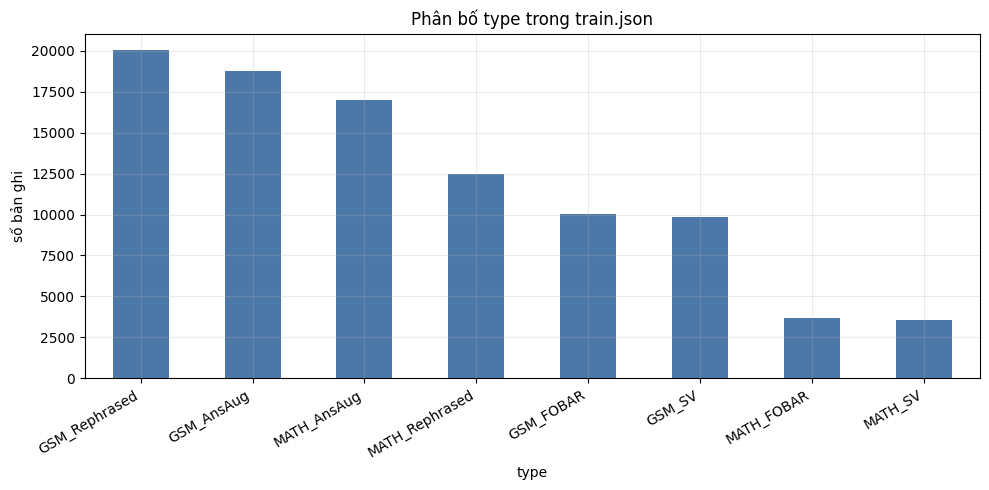

In [9]:
type_table = (
    df["type"]
    .fillna("")
    .replace("", "<missing>")
    .value_counts()
    .rename_axis("type")
    .reset_index(name="count")
)
type_table["ratio"] = type_table["count"] / len(df)
display(type_table)

ax = type_table.plot.bar(x="type", y="count", legend=False, color="#4C78A8")
ax.set_title("Phân bố type trong train.json")
ax.set_xlabel("type")
ax.set_ylabel("số bản ghi")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Độ dài câu hỏi và lời giải

Độ dài văn bản ảnh hưởng trực tiếp đến `max_length`, chi phí huấn luyện và nguy cơ bị cắt chuỗi. Phần này dùng số từ và số ký tự để ước lượng nhanh phân bố độ dài.

,min,p25,p50,p75,p90,p95,p99,max
query_chars,10.0,132.0,198.0,276.0,360.0,419.0,575.0,2310.0
response_chars,14.0,290.0,412.0,606.0,822.0,980.0,1458.0,3444.0
query_words,2.0,31.0,46.0,64.0,83.0,96.0,126.0,311.0
response_words,4.0,68.0,98.0,147.0,201.0,239.0,339.0,772.0


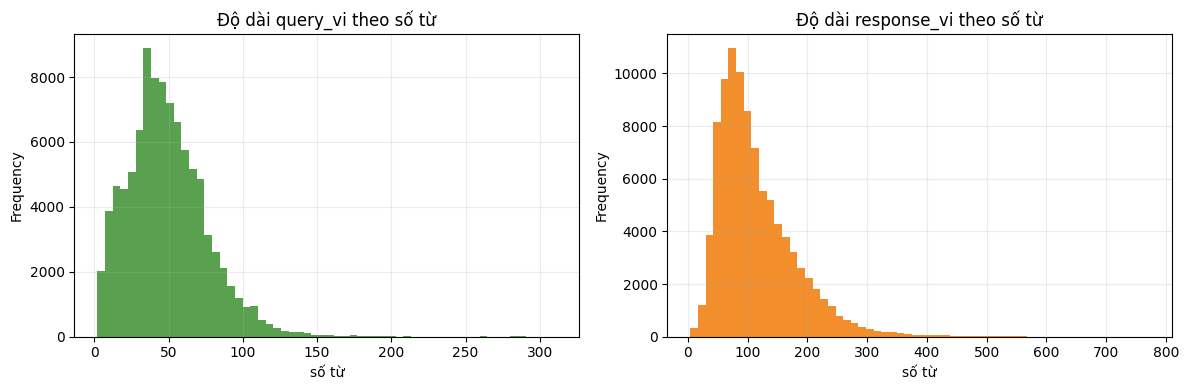

In [10]:
length_cols = ["query_chars", "response_chars", "query_words", "response_words"]
quantiles = df[length_cols].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]).T
quantiles.columns = ["min", "p25", "p50", "p75", "p90", "p95", "p99", "max"]
display(quantiles.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["query_words"].plot.hist(bins=60, ax=axes[0], color="#59A14F")
axes[0].set_title("Độ dài query_vi theo số từ")
axes[0].set_xlabel("số từ")

df["response_words"].plot.hist(bins=60, ax=axes[1], color="#F28E2B")
axes[1].set_title("Độ dài response_vi theo số từ")
axes[1].set_xlabel("số từ")

plt.tight_layout()
plt.show()

## Độ dài theo loại bài

So sánh độ dài theo `type` giúp nhận diện nhóm bài cần cấu hình token dài hơn hoặc nhóm có lời giải ngắn bất thường.

,type,count,query_words_median,query_words_p95,response_words_median,response_words_p95,answer_rate
0,GSM_AnsAug,18745,49.0,92.0,83.0,153.00,1.000
1,GSM_FOBAR,10023,76.0,119.0,144.0,236.00,1.000
2,GSM_Rephrased,20028,47.0,80.0,84.0,155.00,1.000
3,GSM_SV,9869,63.0,107.0,188.0,281.00,1.000
4,MATH_AnsAug,16999,22.0,67.0,74.0,173.00,0.835
5,MATH_FOBAR,3668,58.0,117.0,208.0,430.65,0.993
6,MATH_Rephrased,12477,24.0,58.0,79.0,183.00,0.842
7,MATH_SV,3591,45.0,105.0,171.0,359.00,0.996


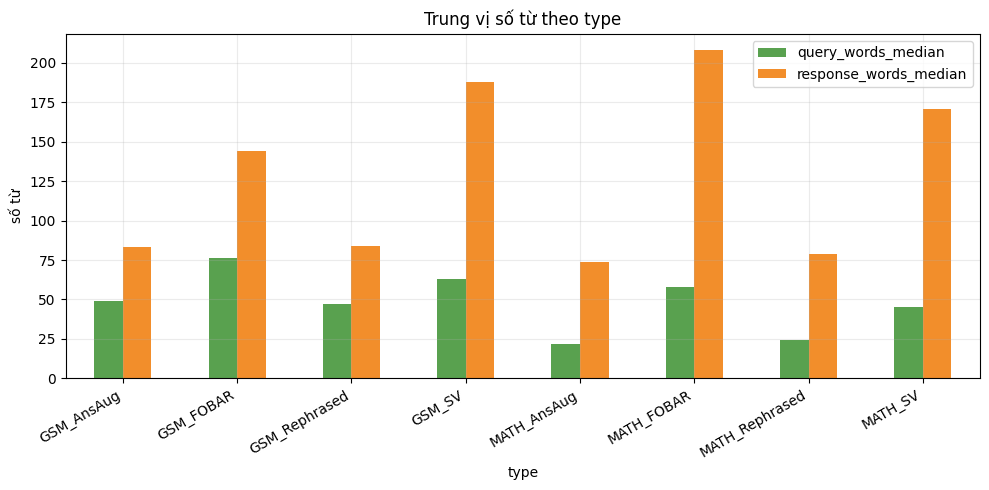

In [11]:
length_by_type = (
    df.groupby("type", dropna=False)
    .agg(
        count=("index", "count"),
        query_words_median=("query_words", "median"),
        query_words_p95=("query_words", lambda s: s.quantile(0.95)),
        response_words_median=("response_words", "median"),
        response_words_p95=("response_words", lambda s: s.quantile(0.95)),
        answer_rate=("has_answer", "mean"),
    )
    .reset_index()
)
display(length_by_type.round(3))

ax = length_by_type.plot.bar(
    x="type",
    y=["query_words_median", "response_words_median"],
    color=["#59A14F", "#F28E2B"],
)
ax.set_title("Trung vị số từ theo type")
ax.set_xlabel("type")
ax.set_ylabel("số từ")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Đáp án số trong lời giải

Bài toán được chấm bằng sai số tương đối trên đáp án số. Vì vậy, cần kiểm tra tỷ lệ `response_vi` có thể trích được đáp án và phân bố độ lớn của đáp án.

,chỉ_số,giá_trị
0,Số bản ghi trích được đáp án,9.057400e+04
1,Tỷ lệ trích được đáp án,9.494000e-01
2,Số đáp án khác nhau,1.420000e+03
3,Đáp án nhỏ nhất,-2.036162e+06
4,Đáp án lớn nhất,1.092000e+08


,answer
count,9.057400e+04
mean,9.429136e+03
std,7.213406e+05
min,-2.036162e+06
50%,2.000000e+01
90%,4.570000e+02
95%,1.520000e+03
99%,3.000000e+04
max,1.092000e+08


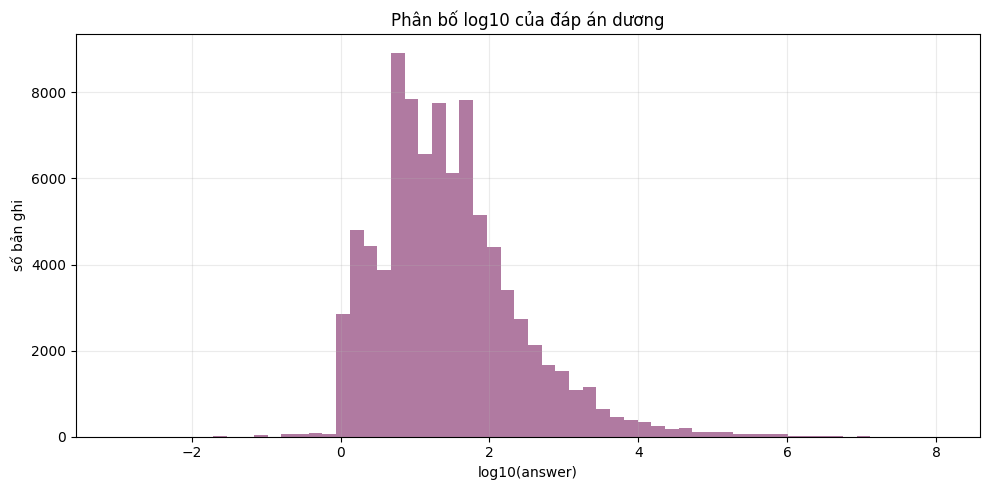

In [12]:
answer_df = df[df["has_answer"]].copy()
answer_summary = pd.DataFrame([
    {"chỉ_số": "Số bản ghi trích được đáp án", "giá_trị": len(answer_df)},
    {"chỉ_số": "Tỷ lệ trích được đáp án", "giá_trị": round(len(answer_df) / len(df), 4)},
    {"chỉ_số": "Số đáp án khác nhau", "giá_trị": answer_df["answer"].nunique()},
    {"chỉ_số": "Đáp án nhỏ nhất", "giá_trị": answer_df["answer"].min()},
    {"chỉ_số": "Đáp án lớn nhất", "giá_trị": answer_df["answer"].max()},
])
display(answer_summary)

display(answer_df["answer"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("answer"))

positive_answers = answer_df[answer_df["answer"] > 0]["answer"]
if len(positive_answers) > 0:
    positive_answers.apply(lambda x: math.log10(x)).plot.hist(bins=60, color="#B07AA1")
    plt.title("Phân bố log10 của đáp án dương")
    plt.xlabel("log10(answer)")
    plt.ylabel("số bản ghi")
    plt.tight_layout()
    plt.show()

## Trùng lặp dữ liệu

Trùng lặp câu hỏi hoặc trùng lặp cặp câu hỏi-lời giải có thể làm mô hình học thuộc mẫu. Bước này đo trùng lặp theo văn bản đã chuẩn hóa khoảng trắng và chữ thường.

In [13]:
duplicate_summary = pd.DataFrame([
    {
        "loại_trùng_lặp": "query_vi",
        "số_hash_trùng": sum(1 for v in query_hash_counter.values() if v > 1),
        "số_bản_ghi_nằm_trong_nhóm_trùng": sum(v for v in query_hash_counter.values() if v > 1),
    },
    {
        "loại_trùng_lặp": "response_vi",
        "số_hash_trùng": sum(1 for v in response_hash_counter.values() if v > 1),
        "số_bản_ghi_nằm_trong_nhóm_trùng": sum(v for v in response_hash_counter.values() if v > 1),
    },
    {
        "loại_trùng_lặp": "query_vi + response_vi",
        "số_hash_trùng": sum(1 for v in pair_hash_counter.values() if v > 1),
        "số_bản_ghi_nằm_trong_nhóm_trùng": sum(v for v in pair_hash_counter.values() if v > 1),
    },
])
display(duplicate_summary)

duplicate_queries = [
    {"count": count, "query_preview": query_first_preview[h]}
    for h, count in query_hash_counter.most_common()
    if count > 1
][:10]

display(pd.DataFrame(duplicate_queries))

,loại_trùng_lặp,số_hash_trùng,số_bản_ghi_nằm_trong_nhóm_trùng
0,query_vi,17228,54827
1,response_vi,357,745
2,query_vi + response_vi,0,0


,count,query_preview
0,16,Có bao nhiêu cách chọn 3 đội trưởng từ một đội 11 người?
1,15,Chữ số hàng đơn vị của tổng $1 là bao nhiêu! + 2! + 3! + 4! + 5! + \cdots + 1000!$?
2,14,"Giả sử $77\cdot 88\cdot 99 \equiv n\pmod{20}$, trong đó $0\le n<20$. Giá trị của $n$ là bao nhiêu?"
3,14,Tìm nghiệm lớn hơn trong hai nghiệm phân biệt của phương trình $$x^2 - 11x - 42 = 0.$$
4,14,Diện tích được bao quanh bởi vùng được xác định bởi phương trình $x^2+y^2+6x+8y=0$ là bao nhiêu?
5,14,"Trong trò chơi Mindmaster, các mã bí mật được tạo bằng cách đặt các chốt có bảy màu khác nhau vào bốn ô. Màu sắc có thể được lặp lại và khôn..."
6,14,"Trong số 100 học sinh của câu lạc bộ khoa học, có 65 học sinh học toán, 43 học sinh học vật lý và 10 học sinh học cả toán và vật lý. Có bao ..."
7,14,Nếu $3x-5=10x+9$ thì $4(x+7)$ là bao nhiêu?
8,13,Tìm giá trị của $x$ sao cho $\sqrt{3x + 7} = 10$.
9,13,"Chuyển đổi điểm $(\rho,\theta,\phi) = \left( 2, \pi, \frac{\pi}{4} \right)$ ở tọa độ hình cầu thành tọa độ hình chữ nhật."


## Mẫu dữ liệu cần kiểm tra thủ công

Các bảng dưới đây giúp xem nhanh một vài bản ghi đầu tiên, câu hỏi dài nhất và lời giải dài nhất. Đây là phần nên đọc thủ công trước khi quyết định cấu hình cắt chuỗi.

In [14]:
display(df[["index", "type", "query_words", "response_words", "answer", "query_preview", "response_preview"]].head(10))

long_queries = df.nlargest(10, "query_words")[["index", "type", "query_words", "query_preview"]]
long_responses = df.nlargest(10, "response_words")[["index", "type", "response_words", "response_preview"]]

print("Câu hỏi dài nhất")
display(long_queries)

print("Lời giải dài nhất")
display(long_responses)

,index,type,query_words,response_words,answer,query_preview,response_preview
0,0,GSM_AnsAug,91,86,1200.0,Bridgette và Alex sắp kết hôn. Bridgette đang mời 84 khách và Alex đang mời 2/3 số khách đó. Họ thuê một người phục vụ ăn uống để chuẩn bị b...,"Bridgette đang mời 84 khách và Alex đang mời 2/3 số khách đó, tức là 84 * 2/3 = 56 khách. Vậy tổng số khách là 84 + 56 = 140 khách. Người ph..."
1,1,MATH_AnsAug,44,45,253.0,"23 người tham dự một bữa tiệc. Mỗi người bắt tay tối đa 22 người khác. Số lần bắt tay tối đa có thể là bao nhiêu, giả sử rằng bất kỳ hai ngư...","Để tối đa hóa số lần bắt tay, mỗi người nên bắt tay với mọi người khác. Tuy nhiên, mỗi người chỉ được bắt tay tối đa 22 người khác. Vì vậy, ..."
2,2,GSM_SV,93,230,2.0,"Bob, Tom, Sally và Jerry ăn tối tại tiệm bánh pizza yêu thích của họ. Họ quyết định chia nhau x pizza. Bob đã tự mình ăn nửa chiếc bánh pizz...","Để giải quyết vấn đề này, chúng ta cần xác định giá trị của x, đại diện cho số lượng pizza mà họ đã chia sẻ. Hãy chia nhỏ thông tin đã cho: ..."
3,3,GSM_AnsAug,80,119,52.0,"Hans đã đặt bàn tại một nhà hàng sang trọng cho 12 người. Anh ta phải đặt cọc để đặt chỗ, số tiền đặt cọc là 20 USD cố định cộng thêm 3 USD ...","Hans đặt bàn cho 12 người, trong đó có 2 trẻ em nên có 12 - 2 = 10 người lớn. Hans phải trả 3$ cho mỗi người lớn nên tổng chi phí cho người ..."
4,4,GSM_SV,66,224,2.0,Diana cần phải đạp xe 10 dặm để về nhà. Cô ấy có thể đạp xe với tốc độ 3 dặm/giờ trong x giờ trước khi cảm thấy mệt và cô ấy có thể đạp xe v...,"Để giải quyết vấn đề này, chúng ta cần xác định giá trị của x, đại diện cho số giờ Diana có thể đạp xe với tốc độ 3 dặm/giờ trước khi cảm th..."
5,5,GSM_FOBAR,57,124,4.0,Bart làm một mixtape. Mặt đầu tiên có 6 bài hát. Mặt thứ hai có x bài hát. Mỗi bài hát có thời lượng 4 phút. Tổng chiều dài băng là bao nhiê...,"Mặt đầu tiên của mixtape có 6 bài hát, mỗi bài có độ dài 4 phút nên tổng độ dài của mặt đầu tiên là 6 * 4 = 24 phút. Mặt thứ 2 của mixtape c..."
6,6,MATH_Rephrased,65,101,20.0,"Giả sử không có khoản hoàn trả nào được thực hiện, sau bao nhiêu ngày Darren và Fergie sẽ nợ số tiền như nhau, biết rằng Darren đã vay 100 đ...",Số tiền Darren nợ Ethan sau $d$ ngày là $100 + 100 \cdot \frac{10}{100} \cdot d = 100 + 10d$ ngao. Số tiền Fergie nợ Gertie sau $d$ ngày là ...
7,7,GSM_FOBAR,63,88,65.0,George có 100 đô la. Anh ấy mua một chiếc áo sơ mi với giá 24 đô la và anh ấy cũng mua một đôi tất. Khi đó anh ta còn lại $x. Một đôi tất ba...,"George có 100 đô la. Anh ấy mua một chiếc áo sơ mi với giá 24 đô la, vậy anh ấy còn lại 100 đô la - 24 đô la = 76 đô la. Anh ấy cũng mua một..."
8,8,MATH_SV,44,226,9.7,"Một hình vuông và một hình tam giác có chu vi bằng nhau. Độ dài ba cạnh của tam giác là $6,1$ cm, $8,2$ cm và X cm. Diện tích hình vuông là ...","Để giải bài toán này, chúng ta cần xác định giá trị của x, biểu thị độ dài cạnh thứ ba của tam giác. Chúng ta biết rằng độ dài ba cạnh của t..."
9,9,GSM_AnsAug,51,101,200.0,Một người thợ thủ công làm được 16 chiếc lọ. Con số này chính xác gấp đôi số chiếc bình đất sét mà ông đã làm ra. Nếu mỗi bình có 5 viên bi ...,Nếu người thợ làm được 16 chiếc lọ thì người đó làm được 16/2 = 8 chiếc lọ đất sét. Nếu mỗi lọ có 5 viên bi thì tổng số lọ có 16 * 5 = 80 vi...


Câu hỏi dài nhất


,index,type,query_words,query_preview
67259,67259,MATH_FOBAR,311,Carolyn và Paul đang chơi một trò chơi bắt đầu với một danh sách các số nguyên $1$ đến $n.$ Luật chơi là: $\bullet$ Carolyn luôn có lượt đầu...
65917,65917,MATH_SV,308,"Đồ thị của $y = f(x)$ được hiển thị bên dưới. [asy] kích thước đơn vị(0,5 cm); func thực(real x) { y thực; if (x >= -3 && x <= 0) {y = -2 - ..."
10878,10878,MATH_SV,302,Carolyn và Paul đang chơi một trò chơi bắt đầu với một danh sách các số nguyên $1$ đến $n.$ Luật chơi là: $\bullet$ Carolyn luôn có lượt đầu...
12879,12879,MATH_SV,302,Carolyn và Paul đang chơi một trò chơi bắt đầu với một danh sách các số nguyên $1$ đến $n.$ Luật chơi là: $\bullet$ Carolyn luôn có lượt đầu...
23308,23308,MATH_SV,302,Carolyn và Paul đang chơi một trò chơi bắt đầu với một danh sách các số nguyên $1$ đến $n.$ Luật chơi là: $\bullet$ Carolyn luôn có lượt đầu...
63237,63237,MATH_SV,302,Carolyn và Paul đang chơi một trò chơi bắt đầu với một danh sách các số nguyên $1$ đến $n.$ Luật chơi là: $\bullet$ Carolyn luôn có lượt đầu...
95313,95313,MATH_SV,302,Carolyn và Paul đang chơi một trò chơi bắt đầu với một danh sách các số nguyên $1$ đến $n.$ Luật chơi là: $\bullet$ Carolyn luôn có lượt đầu...
28096,28096,MATH_SV,298,"Đồ thị của $y = f(x)$ được hiển thị bên dưới. [asy] kích thước đơn vị(0,3 cm); func thực(real x) { y thực; if (x >= -3 && x <= 0) {y = -2 - ..."
47761,47761,MATH_SV,296,Carolyn và Paul đang chơi một trò chơi bắt đầu với một danh sách các số nguyên $1$ đến $n.$ Luật chơi là: $\bullet$ Carolyn luôn có lượt đầu...
77653,77653,MATH_SV,296,"Đồ thị của $y = f(x)$ được hiển thị bên dưới. [asy] kích thước đơn vị(0,3 cm); func thực(real x) { y thực; if (x >= -3 && x <= 0) {y = -2 - ..."


Lời giải dài nhất


,index,type,response_words,response_preview
60862,60862,MATH_FOBAR,772,"Chúng ta được cho rằng $a,$ $b,$ $c$ là các nghiệm của $x^3 + px + q = 0.$ Để tìm giá trị của định thức, chúng ta có thể khai triển nó bằng ..."
30658,30658,MATH_FOBAR,767,Chúng ta có các phương trình: $a = \frac{b + c}{x - 2}$ $b = \frac{a + c}{y - X}$ $c = \frac{a + b}{z - 2}$ Chúng ta cũng được cho các phươn...
56849,56849,MATH_FOBAR,745,"Chúng ta được cho rằng ma trận $\mathbf{M}$ nhân với ma trận đã cho bằng ma trận đẳng thức $\mathbf{I}$. Để tìm giá trị của $X$, chúng ta cầ..."
87497,87497,MATH_FOBAR,712,"Chúng ta biết rằng Isabella đã làm 7 bài kiểm tra toán và nhận được 7 điểm khác nhau, mỗi điểm là số nguyên từ 91 đến $X$. Sau mỗi bài kiểm ..."
39417,39417,MATH_FOBAR,680,Chúng ta muốn tìm giá trị của $X$ trong tình huống đã cho. Chúng ta được biết rằng số học sinh trong lớp tốt nghiệp của Teresa là lớn hơn 50...
19519,19519,MATH_FOBAR,679,Chúng ta muốn tìm giá trị của $X$ trong tình huống đã cho. Chúng ta được cho rằng có các số phức $2n$ thỏa mãn cả $z^{28} - z^{8} - 1 = 0$ v...
87985,87985,MATH_FOBAR,673,Chúng ta muốn tìm giá trị của $X$ trong tình huống đã cho. Để tìm số nguyên nhỏ nhất chia hết cho 7 và có phần dư $X$ khi chia cho bất kỳ số...
63745,63745,MATH_FOBAR,669,"Chúng ta được cho rằng $a,$ $b,$ $c$ là các nghiệm của $x^3 + px + q = 0.$ Để tìm biểu thức của định thức, chúng ta có thể mở rộng nó bằng c..."
76773,76773,MATH_FOBAR,660,Chúng ta muốn tìm giá trị của $X$ trong tình huống đã cho. Chúng ta được phương trình: \[\left\| k \begin{pmatrix} X \\ -3 \end{pmatrix} - \...
82754,82754,MATH_SV,660,"Để giải bài toán này, chúng ta cần xác định các giá trị của p, q và r thỏa mãn phương trình đã cho. Gọi A là ma trận đã cho: A = \begin{pmat..."


## Gợi ý đọc kết quả

Sau khi chạy toàn bộ notebook, nên tập trung vào bốn điểm: tỷ lệ thiếu `query_vi` và `response_vi`, phân bố `type`, các mốc p95 hoặc p99 của độ dài văn bản, và tỷ lệ trích được đáp án số. Các chỉ số này ảnh hưởng trực tiếp đến prompt template, `max_length`, chiến lược lọc dữ liệu và cách đánh giá validation.